In [1]:
import lropt
import cvxpy as cp

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import numpy.random as npr
import numpy.testing as npt
import scipy as sc
import torch
from sklearn.model_selection import train_test_split

In [2]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 30 # number of time periods
theta = 0.05

In [63]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    d_hat = np.array([1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+1)]) # nominal demand
    d_train_temp = d_hat * np.random.uniform(1-theta, 1+theta, (N, n))

    # d_train = []
    # for i, row in enumerate(d_train_temp):
    #     if i%2 == 0:
    #         d_train.append(row[-2:]) # get demand at times t = 2,3 when y = 2
    #     else:
    #         d_train.append(row[:2]) # get demand at times t = 1,2 when y = 1
    # d_train = np.array(d_train)
    
    return d_hat, d_train_temp

In [64]:
d_hat, data = gen_demand_intro(100, seed)
# d_hat = np.array(d_hat[:-1])

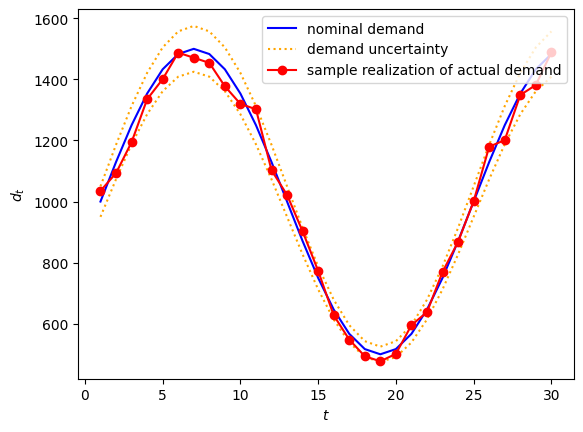

In [65]:
time_periods = np.arange(1,n+1)
plt.plot(time_periods, d_hat, color = "blue", label = "nominal demand")
plt.plot(time_periods, d_hat*(1+theta), linestyle = "dotted", color = "orange", label = "demand uncertainty")
plt.plot(time_periods, d_hat*(1-theta), linestyle = "dotted", color = "orange")
plt.plot(time_periods, data[0], marker = "o", color = "red", label = "sample realization of actual demand")
plt.xlabel("$t$")
plt.ylabel("$d_t$")
plt.legend()

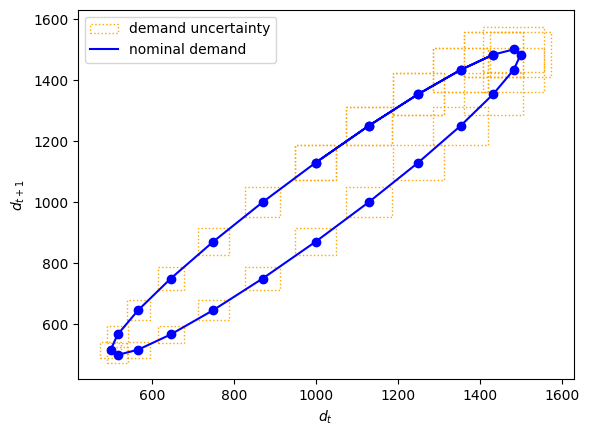

In [66]:
# first point
plt.plot(d_hat[0], d_hat[1], marker = "o", color = "blue")
box_width = 2 * theta * d_hat[0]
box_height = 2 * theta * d_hat[1]
box = Rectangle((d_hat[0] - box_width/2, d_hat[1] - box_height/2), box_width, box_height, 
                linestyle = "dotted", edgecolor='orange', facecolor='none', label = "demand uncertainty")
plt.gca().add_patch(box)

for i in range(1, len(d_hat) - 1):
    plt.plot(d_hat[i], d_hat[i+1], marker = "o", color = "blue")

    # Draw uncertainty box around each point
    box_width = 2 * theta * d_hat[i]
    box_height = 2 * theta * d_hat[i+1]
    box = Rectangle((d_hat[i] - box_width/2, d_hat[i+1] - box_height/2), box_width, box_height, 
                    linestyle = "dotted", edgecolor='orange', facecolor='none')
    plt.gca().add_patch(box)

plt.plot(d_hat[:-1], d_hat[1:], linestyle='-', color='blue', label = "nominal demand")  # Connect points with lines
plt.xlabel("$d_t$")
plt.ylabel("$d_{t+1}$")
plt.legend()

## Training (2 time periods)

In [17]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 2 # 5 # number of time periods

In [18]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    theta = 0.025
    d_hat = [1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, 2*n)] # nominal demand (t = 1, 2, 3)
    d_train_temp = d_hat * np.random.uniform(1-theta, 1+theta, (N, 2*n-1))

    d_train = []
    for i, row in enumerate(d_train_temp):
        d_train.append(row[(i%n):(i%n + 2)]) # get demand time t and t+1
    d_train = np.array(d_train)
    
    return d_hat, d_train

In [19]:
# initialize problem
# cost = np.array([1, 0.87])
cost = [(1 - 0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+1)]
print(cost)
P = np.full(n, 567) # max production capacity at each time period
Q = 1100 # 2700 # max production capacity for all periods
V_min = 500 # minimum inventory
V_max = 2000 # 4000 # maximum inventory
V_1 = 2000 # 4000 # initial inventory
d_hat_all, data = gen_demand_intro(100, seed=15) # demand
d_hat = d_hat_all[:n]
print(d_hat)

[1.0, 0.8705904774487396]
[1000.0, 1129.4095225512604]


In [21]:
# simulating inventories at each time beforehand (no uncertainty in demand)
x = cp.Variable(n)
objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >=0, x<= P]
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(x @ b - d_hat @ b >= V_min - V_1)
    constraints.append(x @ b - d_hat @ b <= V_max - V_1)

prob = cp.Problem(objective, constraints)
prob.solve()
opt_obj = prob.value
opt_prod = x.value
x.value

array([ 62.40952283, 566.9999999 ])

In [22]:
inventories = np.zeros(n)
inventories[0] = V_1
for t in range(1, n):
    inventories[t] = inventories[t-1] + opt_prod[t-1] - d_hat[t-1]

y_data = np.array([[t, inventories[t-1]] for t in range(1, n + 1)])
y_data = np.tile(y_data, (int(100/n), 1))

In [23]:
# need to fix this for more than 2 timesteps (cost dimension doesn't match, can only be length of 2)
y = lropt.Parameter(2, data = y_data) 
u = lropt.UncertainParameter(2, uncertainty_set=lropt.Box(data=data))
x = cp.Variable(2)
objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >= 0, x <= P]

for t in range(n): # for n = 2: one constraint for time t, one constrant for time t and t+1
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    # constraints.append(y @ np.array([0, 1]) + x @ b - u @ b >= V_min)
    # constraints.append(y @ np.array([0, 1]) + x @ b - u @ b <= V_max)
    constraints.append(cp.maximum(y @ np.array([0, 1]) + x @ b - u @ b - V_max, V_min - (y @ np.array([0, 1]) + x @ b - u @ b)) <= 0)

prob = lropt.RobustProblem(objective, constraints)

In [24]:
test_p = 0.1
s = 15
train, _ = train_test_split(data, test_size=int(data.shape[0]*test_p), random_state=s)

initn = sc.linalg.sqrtm(np.cov(train.T)) # * 100
np.random.seed(15)
init_bvaln = np.mean(train, axis=0)

In [10]:
# Train A and b - constant predictor
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD", predictor = "CONSTANT",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=1, position = True, save_history = True)

run 0: test value N/A, violations N/A:   0%|            | 0/100 [00:00<?, ?it/s]/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robus

check gradients here


/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value 427.472, violations 0.5:   2%| | 2/100 [00:00<00:36,  2.71it/s

check gradients here


/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value 427.472, violations 0.5:   3%| | 3/100 [00:01<00:34,  2.83it/s

...

check gradients here


/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value 427.308, violations 0.5:  99%|▉| 99/100 [00:32<00:00,  3.17it/

check gradients here


/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value 427.308, violations 0.5: 100%|█| 100/100 [00:32<00:00,  3.06it

check gradients here


In [12]:
result.df # 1 constraint

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,weightsgrad
0,"(0,)",3301399.941583,427.4716,"[0.5, 0.5]",18118.647363,0.5,"(848.8941849635315,)","([181.68647362923616, 181.68647362923616],)",0.01,"(0.0,)","([0.0, 0.0],)","(tensor(-3270.3552),)","([[tensor(0.1011, dtype=torch.float64), tensor..."
1,"(1,)",9845755.226105,427.471208,"[0.5, 0.5]",18089.214164,0.5,"(848.8920029537198,)","([181.68647362923616, 181.68647362923616],)",0.01,"(3.270355463027954,)","([0.0, 0.0],)","(tensor(-6526.4204),)","([[tensor(0.1003, dtype=torch.float64), tensor..."
2,"(2,)",9786153.840378,427.470505,"[0.5, 0.5]",18006.929813,0.5,"(848.8881001469149,)","([181.68647362923616, 181.68647362923616],)",0.01,"(12.413061141967773,)","([0.0, 0.0],)","(tensor(-6511.6016),)","([[tensor(0.0996, dtype=torch.float64), tensor..."
3,"(3,)",9696280.76323,427.469552,"[0.5, 0.5]",17882.497922,0.5,"(848.8828123792048,)","([181.68647362923616, 181.68647362923616],)",0.01,"(26.238826751708984,)","([0.0, 0.0],)","(tensor(-6489.2124),)","([[tensor(0.0974, dtype=torch.float64), tensor..."
4,"(4,)",9582645.814794,427.468406,"[0.5, 0.5]",17724.549508,0.5,"(848.8764573145263,)","([181.68647362923616, 181.68647362923616],)",0.01,"(43.78865051269531,)","([0.0, 0.0],)","(tensor(-6460.7778),)","([[tensor(0.0902, dtype=torch.float64), tensor..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",1553667.33517,427.298592,"[0.5, 0.5]",1851.932504,0.5,"(847.9407737827764,)","([410.08762391504956, 410.08762391504956],)",0.01001,"(1840.7781982421875,)","([0.0, 0.0],)","(tensor(95.2500),)","([[tensor(0.0896, dtype=torch.float64), tensor..."
96,"(96,)",1553775.328164,427.296688,"[0.5, 0.5]",1852.058482,0.5,"(847.9302876741351,)","([410.08762391504956, 410.08762391504956],)",0.01001,"(1838.79541015625,)","([0.0, 0.0],)","(tensor(-95.2504),)","([[tensor(0.0888, dtype=torch.float64), tensor..."
97,"(97,)",1553917.341704,427.294793,"[0.5, 0.5]",1852.224145,0.5,"(847.9198636687221,)","([410.08762391504956, 410.08762391504956],)",0.01001,"(1837.304443359375,)","([0.0, 0.0],)","(tensor(-95.2508),)","([[tensor(0.0886, dtype=torch.float64), tensor..."
98,"(98,)",1554021.880923,427.292906,"[0.5, 0.5]",1852.346093,0.5,"(847.9094928339597,)","([410.08762391504956, 410.08762391504956],)",0.01001,"(1836.2069091796875,)","([0.0, 0.0],)","(tensor(-95.2510),)","([[tensor(0.1005, dtype=torch.float64), tensor..."


In [11]:
result.df # 2 constraints

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",427.491602,427.4716,"[0.5, 0.0, 0.5, 0.0]",0.01,0.25,"(89.48130389856733,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.22619215683891503,)","([[tensor(0.0935, dtype=torch.float64), tensor..."
1,"(1,)",427.483224,427.471223,"[0.5, 0.0, 0.5, 0.0]",0.005999,0.25,"(89.481084751157,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0040008001960814,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(0.22789465113814703,)","([[tensor(0.0941, dtype=torch.float64), tensor..."
2,"(2,)",427.465573,427.470541,"[0.5, 0.0, 0.5, 0.0]",-0.002483,0.25,"(89.48068866336587,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.01248316839337349,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0003),)","(0.23115121539457004,)","([[tensor(0.0967, dtype=torch.float64), tensor..."
3,"(3,)",427.439382,427.46961,"[0.5, 0.0, 0.5, 0.0]",-0.015113,0.25,"(89.48014753136236,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.025113238021731377,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9998),)","(0.22669124233002796,)","([[tensor(0.0940, dtype=torch.float64), tensor..."
4,"(4,)",427.407701,427.468487,"[0.5, 0.0, 0.5, 0.0]",-0.030396,0.25,"(89.47949497113692,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.040396153926849365,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9992),)","(0.23489771564219425,)","([[tensor(0.1006, dtype=torch.float64), tensor..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",423.743376,427.299255,"[0.5, 0.0, 0.5, 0.0]",-1.810488,0.25,"(89.38128244224808,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-1.8204877376556396,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9277),)","(0.22205527901096114,)","([[tensor(0.0887, dtype=torch.float64), tensor..."
96,"(96,)",423.704311,427.297373,"[0.5, 0.0, 0.5, 0.0]",-1.82978,0.25,"(89.38019200682918,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-1.8397802114486694,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9269),)","(0.223222945956094,)","([[tensor(0.0896, dtype=torch.float64), tensor..."
97,"(97,)",423.66528,427.295494,"[0.5, 0.0, 0.5, 0.0]",-1.849065,0.25,"(89.37910406137185,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-1.8590649366378784,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9261),)","(0.22641859475427545,)","([[tensor(0.0938, dtype=torch.float64), tensor..."
98,"(98,)",423.626275,427.293612,"[0.5, 0.0, 0.5, 0.0]",-1.868342,0.25,"(89.37801432482807,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-1.878341794013977,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9254),)","(0.2228203910343619,)","([[tensor(0.0892, dtype=torch.float64), tensor..."


In [12]:
A_iters, b_iters = result.uncset_iters # A and b at each iteration
print(A_iters[-1][0])
print(b_iters[-1][0])

[[55.67449112 35.31474382]
 [35.30769811 48.93595826]]
[1063.6337278  1189.09058879]


In [13]:
# wrong? not updating from inital values
A_fin, b_fin = result.weights
A_fin = A_fin.numpy()
b_fin = b_fin.numpy()
print(A_fin, b_fin)

[[55.71916595 35.36099064]
 [35.36099064 49.00488726]] [1063.70492654 1189.16743959]


In [13]:
A_fin, b_fin = result.weights
A_fin = A_fin.numpy()
b_fin = b_fin.numpy()
print(A_fin, b_fin)

[[55.67449112 35.31474382]
 [35.30769811 48.93595826]] [[1063.6337278 ]
 [1189.09058879]]


In [15]:
num_p = 50
offset = 2
x_min, x_max = np.min(train[:,0]) - offset, np.max(train[:,0]) + offset
y_min, y_max = np.min(train[:,1]) - offset, np.max(train[:,1]) + offset
X = np.linspace(x_min,x_max,num_p)
Y = np.linspace(y_min,y_max,num_p)
x,y = np.meshgrid(X,Y)

fin_set = np.zeros((num_p,num_p))
for i in range(num_p):
    for j in range(num_p):
        u_vec = [x[i,j], y[i,j]]
        fin_set[i,j] = np.linalg.norm((A_fin.T@np.linalg.inv(A_fin@A_fin.T))@(u_vec - b_fin)) # np.linalg.norm((1/eps_list[inds_reshaped[ind]])*(A_fin.T@np.linalg.inv(A_fin@A_fin.T))@(u_vec - b_fin))

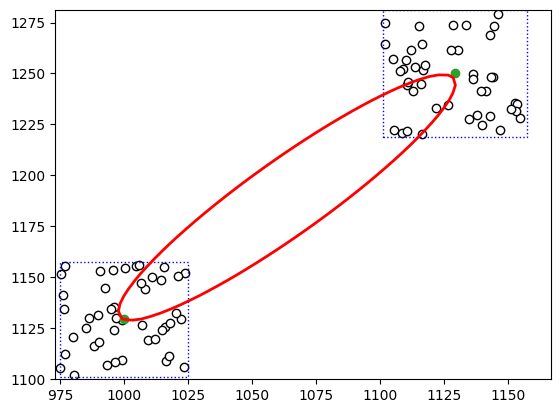

In [23]:
plt.scatter(train[:,0], train[:,1], color = "white",edgecolor = "black")
plt.scatter(d_hat_all[0], d_hat_all[1], color = ["tab:green"])
plt.scatter(d_hat_all[1], d_hat_all[2], color = ["tab:green"])

# box uncertainty set
theta = 0.025
box1_width = 2 * theta * d_hat_all[0]
box1_height = 2 * theta * d_hat_all[1]
box2_height = 2 * theta * d_hat_all[2]
box1 = Rectangle((d_hat_all[0] - box1_width/2, d_hat_all[1] - box1_height/2), box1_width, box1_height, 
                linestyle = "dotted", edgecolor='blue', facecolor='none')
plt.gca().add_patch(box1)
box2 = Rectangle((d_hat_all[1] - box1_height/2, d_hat_all[2] - box2_height/2), box1_height, box2_height, 
                linestyle = "dotted", edgecolor='blue', facecolor='none')
plt.gca().add_patch(box2)

# plot reshaped uncertainty set
plt.contour(x, y, fin_set, [1], colors = ["red"],linewidths = [2])

In [25]:
# Train A and b - linear predictor
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD", predictor = "LINEAR",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=1, position = True, save_history = True)

run 0: test value N/A, violations N/A:   0%|            | 0/100 [00:00<?, ?it/s]/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robus

check gradients here


/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value -0.0, violations 0.75:   2%|  | 2/100 [00:00<00:33,  2.97it/s]

check gradients here


/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value -0.0, violations 0.75:   3%|  | 3/100 [00:00<00:31,  3.05it/s]

...

check gradients here


/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value -0.0, violations 0.75:  99%|▉| 99/100 [00:32<00:00,  3.12it/s]

check gradients here


/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:849: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value -0.0, violations 0.75: 100%|█| 100/100 [00:33<00:00,  3.02it/s

check gradients here


In [26]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,weightsgrad
0,"(0,)",5994325.195094,-0.0,"[0.5, 1.0]",24433.362096,0.75,"(1299378.9977724908,)","([244.83362095705405, 244.83362095705405],)",0.01,"(0.0,)","([0.0, 0.0],)","(tensor(-9303.6533),)","([[tensor(2.3759e-10, dtype=torch.float64), te..."
1,"(1,)",17761481.715489,-0.0,"[0.5, 1.0]",24256.592675,0.75,"(1299378.9977724901,)","([244.83362095705405, 244.83362095705405],)",0.01,"(9.303653717041016,)","([0.0, 0.0],)","(tensor(-18521.1387),)","([[tensor(4.7300e-10, dtype=torch.float64), te..."
2,"(2,)",17283030.199824,-0.0,"[0.5, 1.0]",23763.275502,0.75,"(1299378.9977724883,)","([244.83362095705405, 244.83362095705405],)",0.01,"(35.26771545410156,)","([0.0, 0.0],)","(tensor(-18333.7344),)","([[tensor(4.6821e-10, dtype=torch.float64), te..."
3,"(3,)",16571610.62033,-0.0,"[0.5, 1.0]",23020.280728,0.75,"(1299378.9977724857,)","([244.83362095705405, 244.83362095705405],)",0.01,"(74.3727035522461,)","([0.0, 0.0],)","(tensor(-18051.3770),)","([[tensor(4.6100e-10, dtype=torch.float64), te..."
4,"(4,)",15689825.644679,-0.0,"[0.5, 1.0]",22082.908788,0.75,"(1299378.997772482,)","([244.83362095705405, 244.83362095705405],)",0.01,"(123.70806884765625,)","([0.0, 0.0],)","(tensor(-17695.1680),)","([[tensor(4.5190e-10, dtype=torch.float64), te..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",1411447.158809,-0.0,"[0.5, 1.0]",1852.175371,0.75,"(1299378.9977723253,)","([371.7540301505934, 371.7540301505934],)",0.01001,"(1837.743408203125,)","([0.0, 0.0],)","(tensor(-86.7321),)","([[tensor(3.3864e-11, dtype=torch.float64), te..."
96,"(96,)",1411414.496665,-0.0,"[0.5, 1.0]",1852.133528,0.75,"(1299378.9977723248,)","([371.7540301505934, 371.7540301505934],)",0.01001,"(1838.1199951171875,)","([0.0, 0.0],)","(tensor(-86.7319),)","([[tensor(3.3864e-11, dtype=torch.float64), te..."
97,"(97,)",1411380.849929,-0.0,"[0.5, 1.0]",1852.090423,0.75,"(1299378.9977723244,)","([371.7540301505934, 371.7540301505934],)",0.01001,"(1838.5079345703125,)","([0.0, 0.0],)","(tensor(-86.7318),)","([[tensor(3.3864e-11, dtype=torch.float64), te..."
98,"(98,)",1411346.409176,-0.0,"[0.5, 1.0]",1852.046302,0.75,"(1299378.9977723241,)","([371.7540301505934, 371.7540301505934],)",0.01001,"(1838.905029296875,)","([0.0, 0.0],)","(tensor(-86.7318),)","([[tensor(3.3864e-11, dtype=torch.float64), te..."


In [27]:
w_a, intcpt_a, w_b, intcpt_b = result.weights
w_a = w_a.numpy()
intcpt_a = intcpt_a.numpy()
w_b = w_b.numpy()
intcpt_b = intcpt_b.numpy()
print(w_a, intcpt_a)
print(w_b, intcpt_b)

[[55.71916595 35.36099059]
 [35.36099064 49.0048872 ]
 [55.71916595 35.36099068]
 [35.36099064 49.00488732]] [[-1.08858365 -0.2665963 ]
 [ 0.18942346 -0.21902281]]
[[1063.70492654 1063.70492654]
 [1189.16743959 1189.16743959]] [[1.09925053]
 [2.75653831]]


In [35]:
# do this for the different y's
A_fin1 = (w_a @ y_data[0]) + intcpt_a
A_fin1 = A_fin1.reshape(2, 2)
print(A_fin1)

A_fin2 = (w_a @ y_data[1]) + intcpt_a
A_fin2 = A_fin2.reshape(2, 2)
print(A_fin2)

[[70778.07083396 98046.59200946]
 [70778.64025034 98045.91035568]]
[[37679.6619152  52135.43737219]
 [37680.23133157 52134.7557184 ]]


In [36]:
# do the same thing for b
b_fin1 = (w_b @ y_data[0]) + intcpt_b
print(b_fin1)

b_fin2 = (w_b @ y_data[1]) + intcpt_b
print(b_fin2)

[2128473.53711794 2379523.32814165]
[1132217.63240772 1265760.42846193]


In [37]:
num_p = 50
offset = 2
x_min, x_max = np.min(train[:,0]) - offset, np.max(train[:,0]) + offset
y_min, y_max = np.min(train[:,1]) - offset, np.max(train[:,1]) + offset
X = np.linspace(x_min,x_max,num_p)
Y = np.linspace(y_min,y_max,num_p)
x,y = np.meshgrid(X,Y)

fin_set1 = np.zeros((num_p,num_p))
fin_set2 = np.zeros((num_p,num_p))
for i in range(num_p):
    for j in range(num_p):
        u_vec = [x[i,j], y[i,j]]
        fin_set1[i,j] = np.linalg.norm((A_fin1.T@np.linalg.inv(A_fin1@A_fin1.T))@(u_vec - b_fin1))
        fin_set2[i,j] = np.linalg.norm((A_fin2.T@np.linalg.inv(A_fin2@A_fin2.T))@(u_vec - b_fin2))

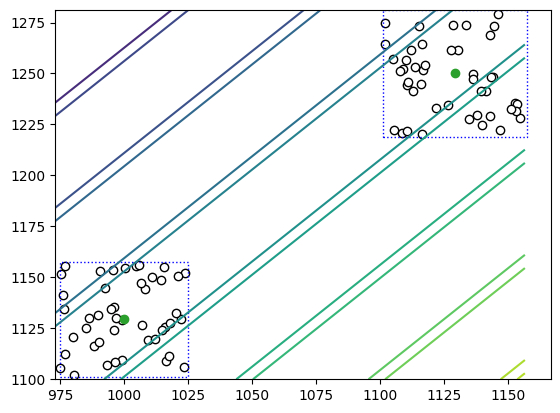

In [43]:
plt.scatter(train[:,0], train[:,1], color = "white",edgecolor = "black")
plt.scatter(d_hat_all[0], d_hat_all[1], color = ["tab:green"])
plt.scatter(d_hat_all[1], d_hat_all[2], color = ["tab:green"])

# box uncertainty set
theta = 0.025
box1_width = 2 * theta * d_hat_all[0]
box1_height = 2 * theta * d_hat_all[1]
box2_height = 2 * theta * d_hat_all[2]
box1 = Rectangle((d_hat_all[0] - box1_width/2, d_hat_all[1] - box1_height/2), box1_width, box1_height, 
                linestyle = "dotted", edgecolor='blue', facecolor='none')
plt.gca().add_patch(box1)
box2 = Rectangle((d_hat_all[1] - box1_height/2, d_hat_all[2] - box2_height/2), box1_height, box2_height, 
                linestyle = "dotted", edgecolor='blue', facecolor='none')
plt.gca().add_patch(box2)

# plot reshaped uncertainty set
plt.contour(x, y, fin_set1) # , [1], colors = ["red"],linewidths = [2])
plt.contour(x, y, fin_set2) # , [1], colors = ["red"],linewidths = [2])

## ARO

In [89]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 2 # 5 # number of time periods

In [90]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    theta = 0.025
    d_hat = [1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, 2*n)] # nominal demand (t = 1, 2, 3)
    d_train_temp = d_hat * np.random.uniform(1-theta, 1+theta, (N, 2*n-1))

    d_train = []
    for i, row in enumerate(d_train_temp):
        d_train.append(row[(i%n):(i%n + 2)]) # get demand time t and t+1
    d_train = np.array(d_train)
    
    return d_hat, d_train

In [91]:
# initialize problem
# cost = np.array([1, 0.87])
cost = [(1 - 0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+1)]
print(cost)
P = np.full(n, 567) # max production capacity at each time period
Q = 1100 # 2700 # max production capacity for all periods
V_min = 500 # minimum inventory
V_max = 2000 # 4000 # maximum inventory
V_1 = 2000 # 4000 # initial inventory
d_hat_all, data = gen_demand_intro(100, seed=15) # demand
d_hat = d_hat_all[:n]
print(d_hat)

[1.0, 0.8705904774487396]
[1000.0, 1129.4095225512604]


In [93]:
# simulating inventories at each time beforehand (no uncertainty in demand)
x = cp.Variable(n)
objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >=0, x<= P]
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(x @ b - d_hat @ b >= V_min - V_1)
    constraints.append(x @ b - d_hat @ b <= V_max - V_1)

prob = cp.Problem(objective, constraints)
prob.solve()
opt_obj = prob.value
opt_prod = x.value
x.value

array([ 62.40952283, 566.9999999 ])

In [94]:
inventories = np.zeros(n)
inventories[0] = V_1
for t in range(1, n):
    inventories[t] = inventories[t-1] + opt_prod[t-1] - d_hat[t-1]

y_data = np.array([[t, inventories[t-1]] for t in range(1, n + 1)])
y_data = np.tile(y_data, (int(100/n), 1))

In [95]:
# need to fix this for more than 2 timesteps (cost dimension doesn't match, can only be length of 2)
y = lropt.Parameter(2, data = y_data) 
u = lropt.UncertainParameter(2, uncertainty_set=lropt.Box(data=data))
p_0 = cp.Variable(2)
q = cp.Variable((2, 2))
x = cp.Variable(2)

objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >= 0, x <= P]
for t in range(n): # for n = 2: one constraint for time t, one constrant for time t and t+1
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(cp.maximum(y @ np.array([0, 1]) + x @ b - u @ b - V_max, V_min - (y @ np.array([0, 1]) + x @ b - u @ b)) <= 0)
constraints.append(q[0][0] == 0)
constraints.append(q[0][1] == 0)
constraints.append(q[1][1] == 0)
constraints.append(x == np.identity(2) @ p_0 + q @ u)

prob = lropt.RobustProblem(objective, constraints)

In [96]:
test_p = 0.1
s = 15
train, _ = train_test_split(data, test_size=int(data.shape[0]*test_p), random_state=s)

initn = sc.linalg.sqrtm(np.cov(train.T))
np.random.seed(15)
init_bvaln = np.mean(train, axis=0)

In [ ]:
# Train A and b - constant predictor
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD", predictor = "CONSTANT",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=1, position = True, save_history = True)

In [ ]:
# Train A and b - linear predictor
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD", predictor = "LINEAR",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=1, position = True, save_history = True)